# Data and Packages

In [1]:
# Main Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Clustering 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Parallel processing 
from joblib import Parallel, delayed

In [ ]:
# Time constants
seconds_in_day = 60 * 60 * 24 
minutes_per_week = 7 * 24 * 60 
n_weeks = 8     
eight_weeks_seconds = n_weeks * minutes_per_week * 60

In [3]:
# k in k-means
k_optimal = 2

In [ ]:
# Load data and filter for human users & first 8 weeks of data
df = (
    pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz", has_header=False, separator=",",
                new_columns=['time','src_user','dest_user','src_comp','dest_comp',
                              'auth_type','logon_type','auth_orientation','outcome'])
    .filter(pl.col('src_user').str.starts_with('U'))
    .filter(pl.col('time') < eight_weeks_seconds)
    .collect(engine='streaming')
)

In [5]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

## Functions

In [6]:
# Build the features dataframe
def build_features(df, agg_minutes):

    agg_seconds = agg_minutes * 60

    return (
        df.lazy()
        .with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day) / seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user', 'bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [7]:
def cluster_preprocess(features_df, X_scaled, week, buckets_per_week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

In [8]:
def fit_kmeans(features_df, X_scaled, week, k, buckets_per_week):

    features_week, X_scaled_week = cluster_preprocess(features_df, X_scaled, week,buckets_per_week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (
        features_week.with_columns(pl.Series('cluster', labels))
        .select(['src_user', 'bucket', 'cluster'])
    )

    return week, features_week

In [9]:
def ari_by_week(df, agg_hours, k):

    agg_minutes = round(agg_hours * 60)  
    buckets_per_week = minutes_per_week // agg_minutes

    
    features_df = build_features(df, agg_minutes)

    
    X = features_df.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

   
    weekly_results = dict(
        Parallel(n_jobs=-1)(
            delayed(fit_kmeans)(features_df, X_scaled, week, k,buckets_per_week) for week in range(1, n_weeks + 1)
        )
    )

   
    ARI_scores = {}

    for week in range(1, n_weeks):

        w_curr = weekly_results[week].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week
        )

        w_next = weekly_results[week + 1].with_columns(
            relative_bucket = pl.col('bucket') % buckets_per_week
        )

        overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

        labels_curr = overlap['cluster'].to_numpy()
        labels_next = overlap['cluster_next'].to_numpy()

        ARI_scores[(week, week + 1)] = adjusted_rand_score(labels_curr, labels_next)

    return ARI_scores


In [10]:
transition_labels = ['1-2', '2-3', '3-4', '4-5', '5-6', '6-7', '7-8']

# 1 Hour

In [11]:
ARI_scores_1h = ari_by_week(df, agg_hours=1,k = k_optimal)

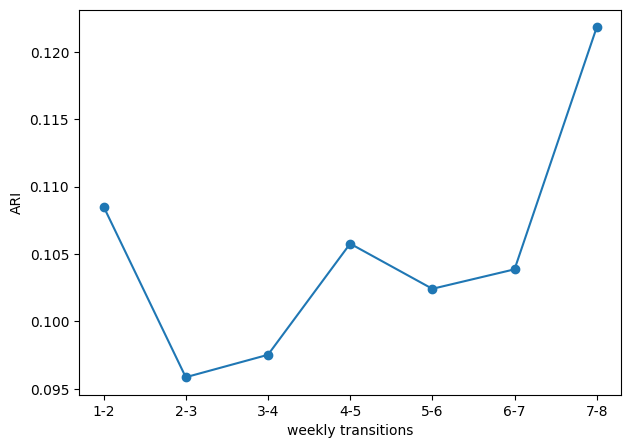

In [12]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_1h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 2 Hours

In [13]:
ARI_scores_2h = ari_by_week(df, agg_hours=2,k = k_optimal)

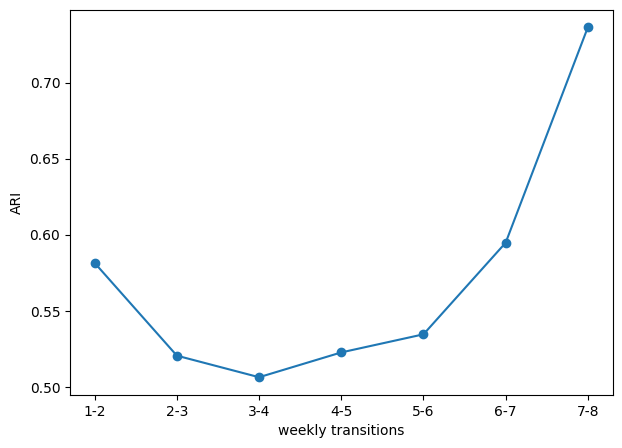

In [14]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_2h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 3 Hours

In [15]:
ARI_scores_3h = ari_by_week(df, agg_hours=3,k = k_optimal)

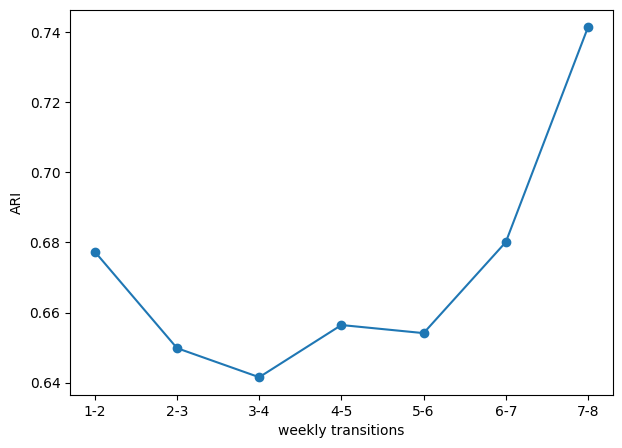

In [16]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_3h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 4 Hours

In [17]:
ARI_scores_4h = ari_by_week(df, agg_hours=4,k = k_optimal)

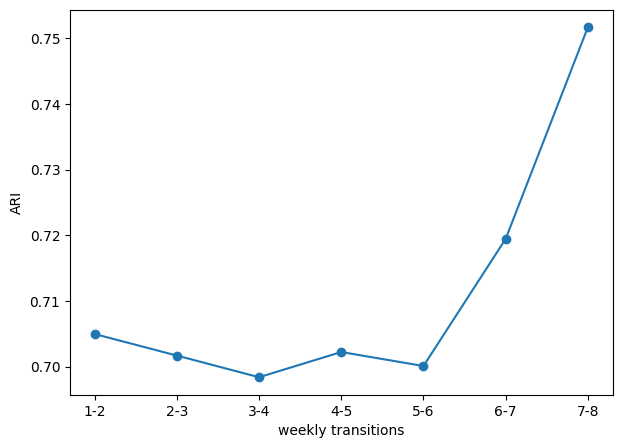

In [18]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_4h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 6 Hours

In [19]:
ARI_scores_6h = ari_by_week(df, agg_hours=6,k = k_optimal)

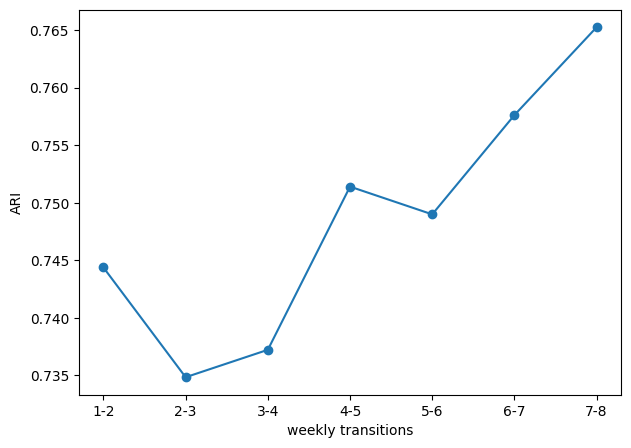

In [20]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_6h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 8 Hours

In [21]:
ARI_scores_8h = ari_by_week(df, agg_hours=8,k = k_optimal)

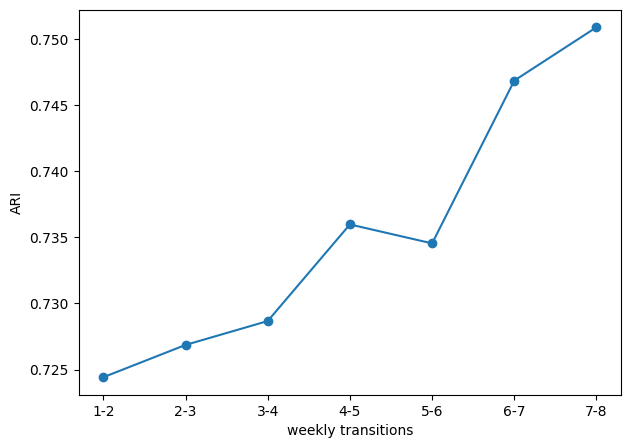

In [22]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_8h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 12 Hours

In [23]:
ARI_scores_12h = ari_by_week(df, agg_hours=12,k = k_optimal)

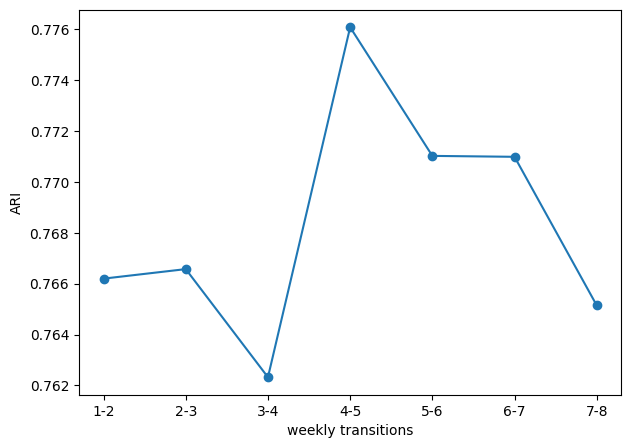

In [24]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_12h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 24 Hours

In [25]:
ARI_scores_24h = ari_by_week(df, agg_hours=24,k = k_optimal)

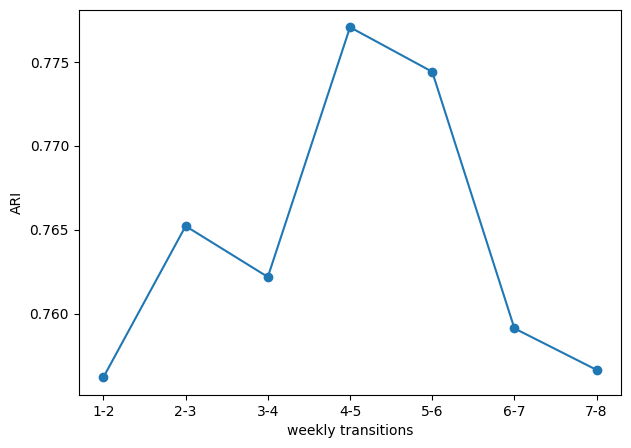

In [26]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_24h.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 10 Minutes

In [27]:
ARI_scores_10m = ari_by_week(df, agg_hours= 1/6,k = k_optimal)

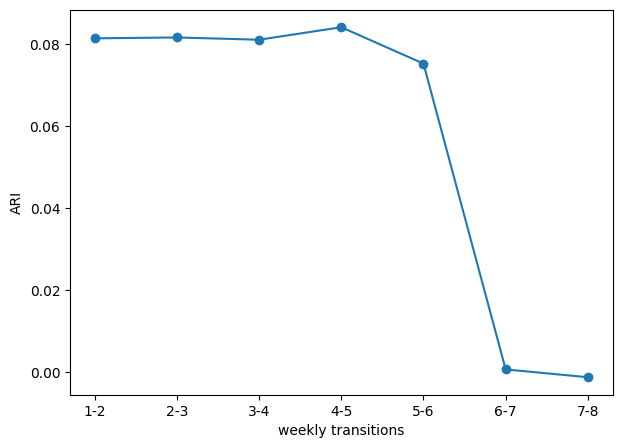

In [28]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_10m.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 1 Minute

In [29]:
ARI_scores_1m = ari_by_week(df, agg_hours= 1/60,k = k_optimal)

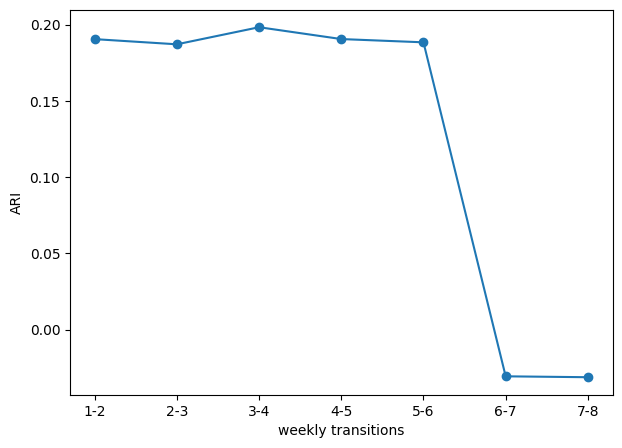

In [30]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_1m.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# 30 Minutes

In [31]:
ARI_scores_30m = ari_by_week(df, agg_hours=0.5,k = k_optimal)

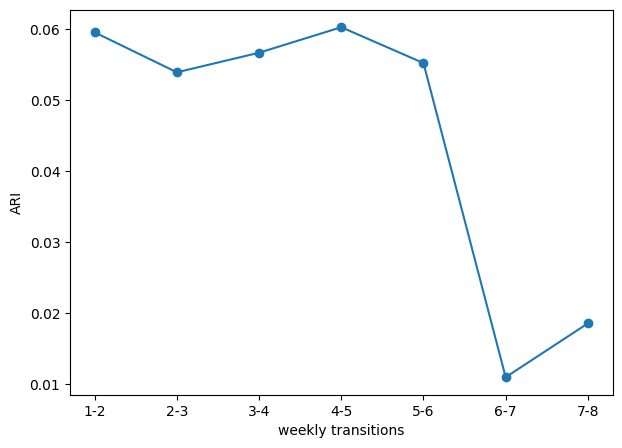

In [32]:
fig, ax = plt.subplots(figsize = (7,5))

plt.plot(list(ARI_scores_30m.values()), marker = 'o')
plt.ylabel('ARI')
plt.xlabel('weekly transitions')
plt.xticks(ticks=range(len(transition_labels)), labels=transition_labels);

# Cominbed ARI plots

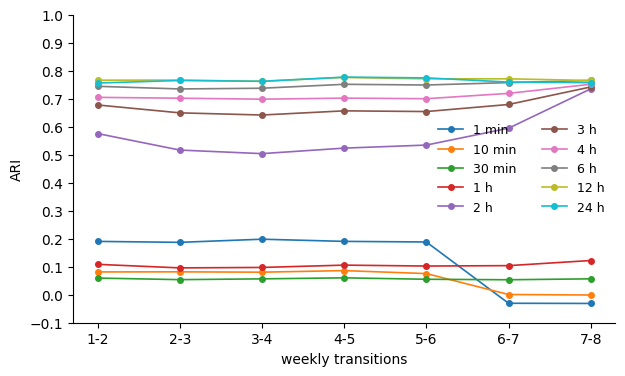

In [ ]:
all_ari = {
    '1 min':  ARI_scores_1m,
    '10 min': ARI_scores_10m,
    '30 min': ARI_scores_30m,
    '1 h':    ARI_scores_1h,
    '2 h':    ARI_scores_2h,
    '3 h':    ARI_scores_3h,
    '4 h':    ARI_scores_4h,
    '6 h':    ARI_scores_6h,
    '12 h':   ARI_scores_12h,
    '24 h':   ARI_scores_24h,
}

fig, ax = plt.subplots(figsize=(7, 4))

for label, ari_scores in all_ari.items():
    ax.plot(list(ari_scores.values()), marker='o', ms=4, lw=1.2, label=label)

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(-0.1, 1.01, 0.1))
ax.set_xticks(range(len(transition_labels)))
ax.set_xticklabels(transition_labels)
ax.set_xlabel('weekly transitions')
ax.set_ylabel('ARI')
ax.legend(frameon=False, ncol=2, fontsize=9)


/tmp/ipykernel_770591/3818334033.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc='lower right')


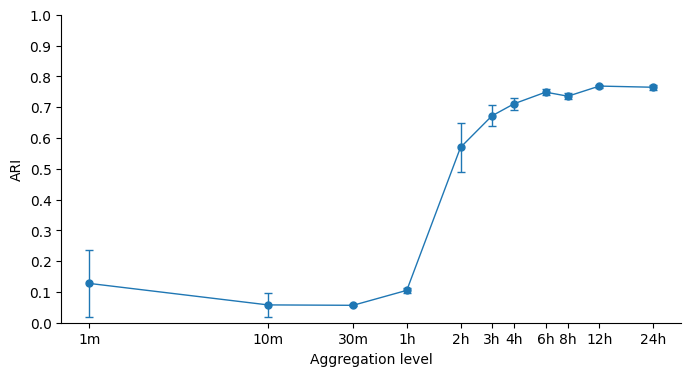

In [ ]:
ari_levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

ari_series = [ARI_scores_1m, ARI_scores_10m, ARI_scores_30m, ARI_scores_1h,
              ARI_scores_2h, ARI_scores_3h, ARI_scores_4h, ARI_scores_6h, 
              ARI_scores_8h, ARI_scores_12h, ARI_scores_24h]


hours = np.array(list(ari_levels.values()))
means = np.array([np.mean(list(s.values())) for s in ari_series])
sds = np.array([np.std(list(s.values()), ddof=1) for s in ari_series])

fig, ax = plt.subplots(figsize=(8, 4)) 

ax.errorbar(hours, means, yerr=sds, marker='o', ms=5, lw=1,
            color='tab:blue', capsize=3, elinewidth=1)

ax.set_xscale('log')
ax.set_xticks(hours)
ax.set_xticklabels(['1m', '10m', '30m', '1h', '2h', '3h', '4h', '6h', '8h', '12h', '24h'])
ax.minorticks_off()

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.01, 0.1))

ax.set_xlabel('Aggregation level')
ax.set_ylabel('ARI')
ax.legend(frameon=False, loc='lower right')


In [51]:
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

In [49]:
results = {name: ari_by_week(df, h, k_optimal) for name, h in levels.items()}

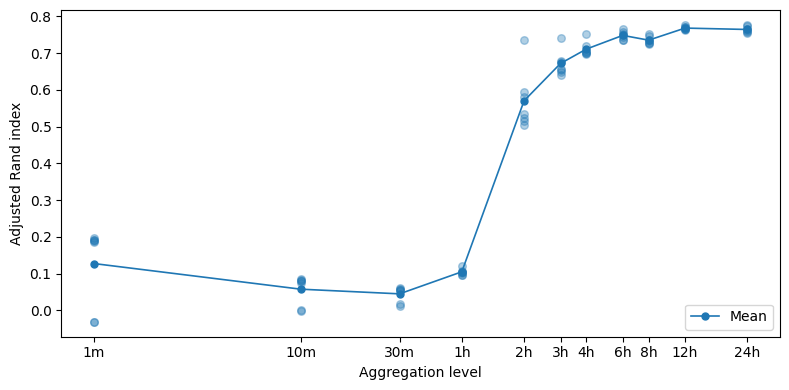

In [ ]:
# Plot of ARIs & mean for each aggregtion level
fig, ax = plt.subplots(figsize=(8, 4))

agg_levels = np.array([h for _, h in levels.items() ])
adj_rand = [np.array(list(results[name].values())) for name in levels]

means = np.array([ari.mean() for ari in adj_rand])

for x, aris in zip(agg_levels, adj_rand):
    ax.scatter(x * np.ones(len(aris)), aris, color='tab:blue', alpha=0.35, s=30, zorder=2)

ax.plot(agg_levels, means , marker='o', ms=5, lw=1.2, zorder=3, label='Mean')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Adjusted Rand index')
ax.legend(loc='lower right')
plt.tight_layout()